# Regressao Linear via Rede Neural - AGRO3 (Dataset Indicadores)
## Analise comparativa de modelos de Machine Learning - Agro Brasil - TCC

Este notebook implementa modelos de regressao linear via rede neural para prever o preco de fechamento futuro das acoes AGRO3 em diferentes horizontes temporais (3, 7, 15 e 30 dias).

### Importacao das bibliotecas e carregamento do dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from scipy import stats
import os

# Configuracao para salvar graficos
OUTPUT_DIR = './'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Carrega o dataset tratado
df = pd.read_csv('../../../../datasets/datasets_indicadores/regressao/AGRO3_tratado.csv')

print('='*60)
print('DATASET AGRO3 - REGRESSAO LINEAR VIA REDE NEURAL (INDICADORES)')
print('='*60)
print('\nPrimeiras 5 linhas do DataFrame:')
print(df.head())

print('\nInformacoes gerais do DataFrame:')
print(df.info())

print('\nEstatisticas descritivas:')
print(df.describe())

DATASET AGRO3 - REGRESSAO LINEAR VIA REDE NEURAL (INDICADORES)

Primeiras 5 linhas do DataFrame:
         Date     Close      High       Low      Open  Volume  Close_3d_fut  \
0  2018-01-29  7.465568  7.510439  7.409477  7.510439   12100      7.560920   
1  2018-01-30  7.454350  7.493612  7.358997  7.493612   29000      7.566530   
2  2018-01-31  7.516049  7.516049  7.375824  7.431914   59500      7.459959   
3  2018-02-01  7.560920  7.740408  7.454349  7.504830   72900      7.398259   
4  2018-02-02  7.566530  7.628229  7.381434  7.560921   60600      7.572138   

   Close_7d_fut  Close_15d_fut  Close_30d_fut     OBV      FWMA      TEMA  \
0      7.572138       7.656273       7.454350   52300  7.469487  7.489368   
1      7.572138       7.740409       7.403867   23300  7.463770  7.481305   
2      7.544093       7.706754       7.375823   82800  7.483749  7.496019   
3      7.566530       7.684318       7.336561  155700  7.513267  7.522017   
4      7.611401       7.628228       7.2916

### Preparacao dos dados para modelagem

In [2]:
# Definir variaveis independentes (features)
X = df[['Close', 'Low', 'High', 'Open']]

# Definir targets (variaveis dependentes) - janelas temporais
targets = {
    '3d': df['Close_3d_fut'],
    '7d': df['Close_7d_fut'],
    '15d': df['Close_15d_fut'],
    '30d': df['Close_30d_fut']
}

print('Variaveis independentes (X):')
print(X.columns.tolist())
print(f'\nShape de X: {X.shape}')

print('\nTargets (janelas temporais):')
for name, target in targets.items():
    print(f'  - {name}: {target.name}')

Variaveis independentes (X):
['Close', 'Low', 'High', 'Open']

Shape de X: (1689, 4)

Targets (janelas temporais):
  - 3d: Close_3d_fut
  - 7d: Close_7d_fut
  - 15d: Close_15d_fut
  - 30d: Close_30d_fut


### Treinamento dos Modelos de Regressao Linear via Rede Neural

In [3]:
print('MODELOS DE REGRESSAO LINEAR VIA REDE NEURAL - AGRO3 (INDICADORES)')
print('='*60)

# Dicionario para armazenar modelos treinados e metricas
models = {}

mlp_params = {
    'hidden_layer_sizes': (64, 32),
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 0.0001,
    'learning_rate_init': 0.001,
    'max_iter': 1000,
    'random_state': 42
}

for period, y in targets.items():
    # Divisao treino-teste (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    # Pipeline com normalizacao + MLPRegressor
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(**mlp_params))
    ])
    model.fit(X_train, y_train)

    # Fazer predicoes
    y_pred = model.predict(X_test)

    # Calcular metricas
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Armazenar modelo e metricas
    models[period] = {
        'model': model,
        'r2': r2,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred
    }

    print(f'\nMODELO {period.upper()} - Predicao Close {period} futuro:')
    print(f'  R2: {r2:.4f}')
    print(f'  MAE: {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')

print('\n' + '='*60)
print('OK - 4 modelos treinados com sucesso!')
print('='*60)

MODELOS DE REGRESSAO LINEAR VIA REDE NEURAL - AGRO3 (INDICADORES)

MODELO 3D - Predicao Close 3d futuro:
  R2: 0.9894
  MAE: 0.4108
  RMSE: 0.6136

MODELO 7D - Predicao Close 7d futuro:
  R2: 0.9780
  MAE: 0.6050
  RMSE: 0.8775

MODELO 15D - Predicao Close 15d futuro:
  R2: 0.9541
  MAE: 0.9014
  RMSE: 1.2740

MODELO 30D - Predicao Close 30d futuro:
  R2: 0.9190
  MAE: 1.2234
  RMSE: 1.6779

OK - 4 modelos treinados com sucesso!


### Tabela Resumo das Metricas

In [4]:
# Criar DataFrame com resumo das metricas
metrics_summary = pd.DataFrame({
    'Horizonte': ['3 dias', '7 dias', '15 dias', '30 dias'],
    'R2': [models['3d']['r2'], models['7d']['r2'], models['15d']['r2'], models['30d']['r2']],
    'MAE': [models['3d']['mae'], models['7d']['mae'], models['15d']['mae'], models['30d']['mae']],
    'RMSE': [models['3d']['rmse'], models['7d']['rmse'], models['15d']['rmse'], models['30d']['rmse']]
})

print('\nRESUMO DAS METRICAS - AGRO3 (INDICADORES)')
print('='*60)
print(metrics_summary.to_string(index=False))

# Salvar metricas em CSV
metrics_summary.to_csv(f'{OUTPUT_DIR}metricas_agro3_indicadores.csv', index=False)
print('\nOK - Metricas salvas em metricas_agro3_indicadores.csv')


RESUMO DAS METRICAS - AGRO3 (INDICADORES)
Horizonte       R2      MAE     RMSE
   3 dias 0.989433 0.410776 0.613612
   7 dias 0.978027 0.605034 0.877465
  15 dias 0.954085 0.901449 1.274023
  30 dias 0.919012 1.223359 1.677860

OK - Metricas salvas em metricas_agro3_indicadores.csv


---
# Analises Graficas

### Graficos de Serie Temporal - Real vs Predito

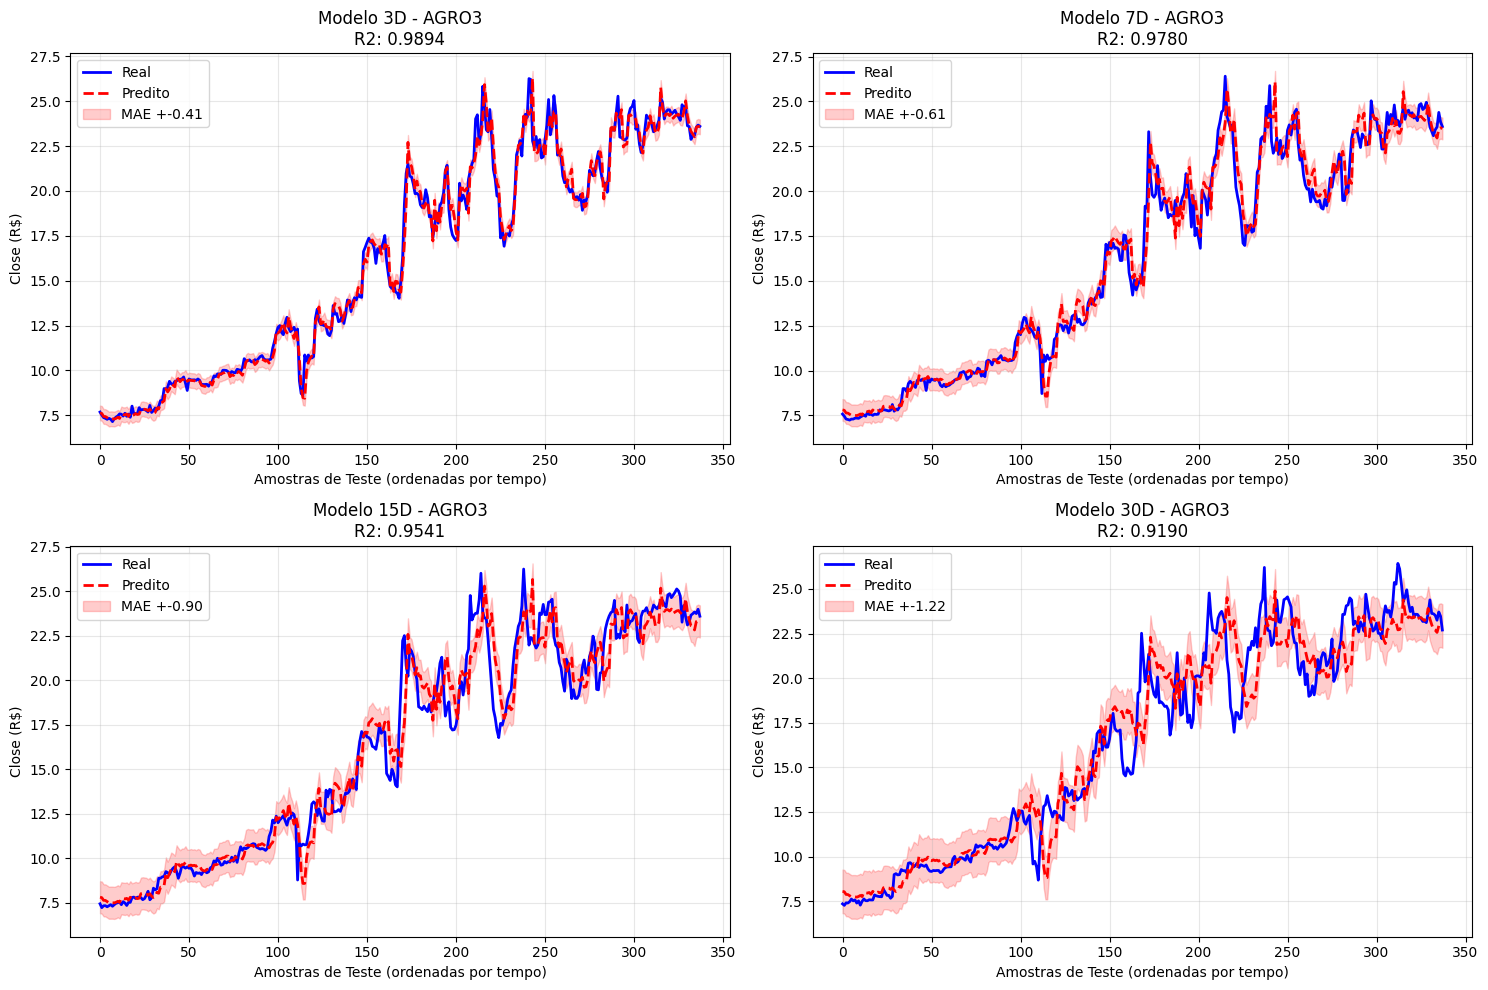

OK - Grafico de serie temporal salvo


In [5]:
# Graficos de serie temporal
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    mae = model_data['mae']

    # Ordenar por indice para visualizacao temporal
    test_indices = model_data['X_test'].index
    sorted_indices = sorted(range(len(test_indices)), key=lambda i: test_indices[i])

    y_test_sorted = y_test.iloc[sorted_indices]
    y_pred_sorted = y_pred[sorted_indices]

    # Plotar
    ax = axes[idx]
    ax.plot(range(len(y_test_sorted)), y_test_sorted, 'b-', label='Real', linewidth=2)
    ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'r--', label='Predito', linewidth=2)

    # Adicionar tunel do MAE
    ax.fill_between(range(len(y_pred_sorted)),
                    y_pred_sorted - mae,
                    y_pred_sorted + mae,
                    alpha=0.2, color='red', label=f'MAE +-{mae:.2f}')

    ax.set_title(f'Modelo {period.upper()} - AGRO3\nR2: {model_data["r2"]:.4f}')
    ax.set_xlabel('Amostras de Teste (ordenadas por tempo)')
    ax.set_ylabel('Close (R$)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}serie_temporal_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico de serie temporal salvo')

### Graficos de Residuos

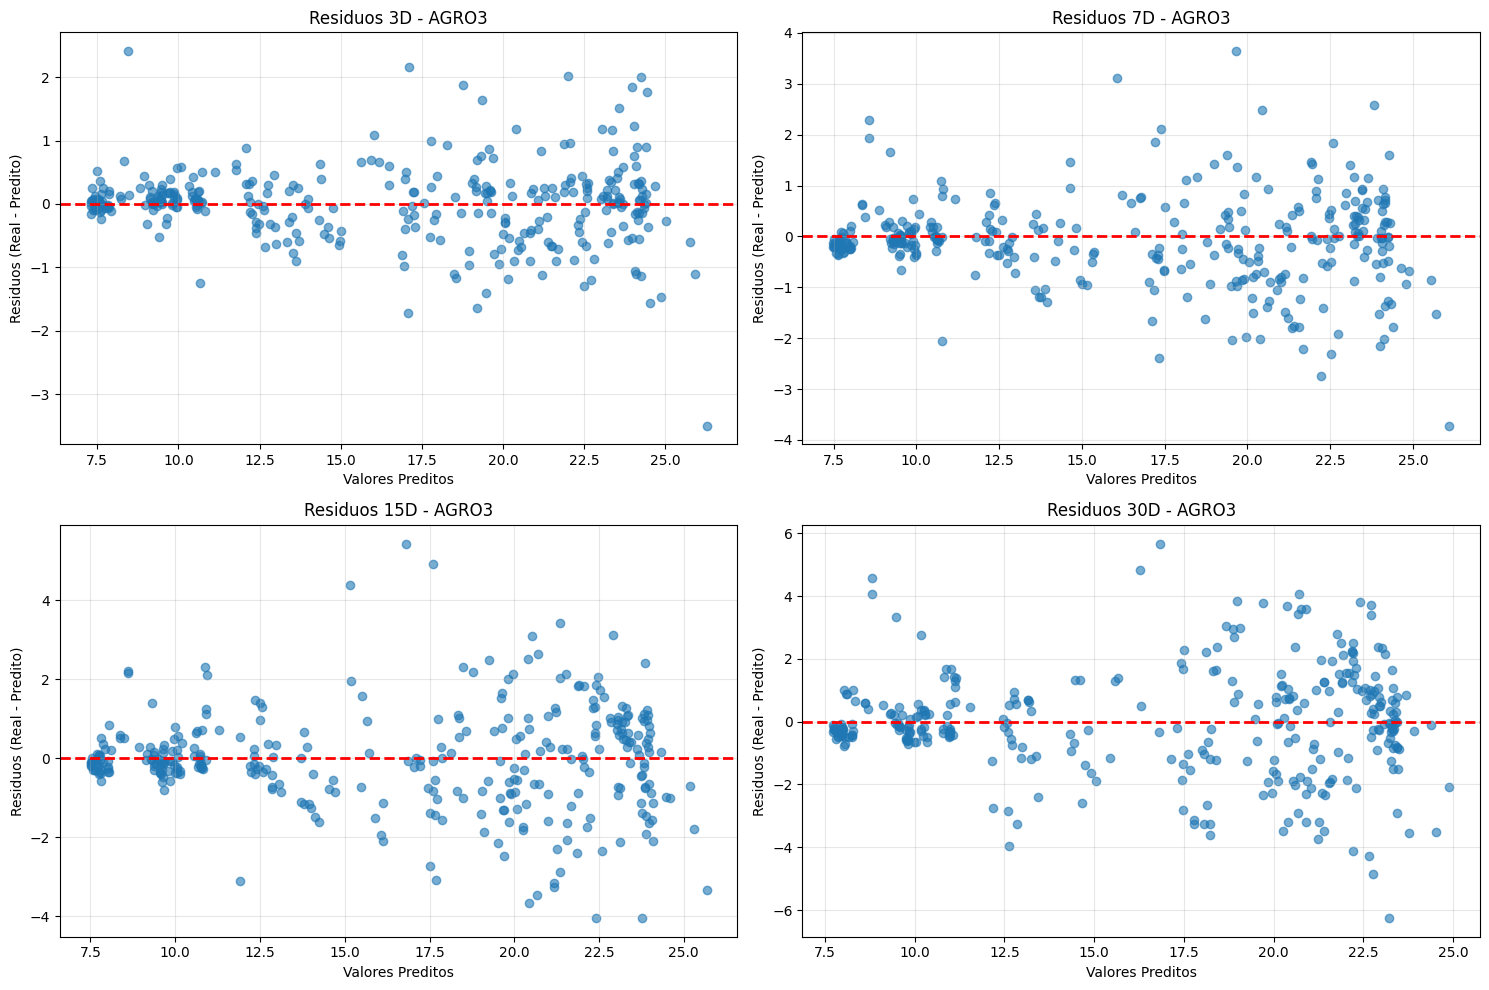

OK - Grafico de residuos salvo


In [6]:
# Graficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    residuos = y_test - y_pred

    # Plotar
    ax = axes[idx]
    ax.scatter(y_pred, residuos, alpha=0.6)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Residuos {period.upper()} - AGRO3')
    ax.set_xlabel('Valores Preditos')
    ax.set_ylabel('Residuos (Real - Predito)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}residuos_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico de residuos salvo')

### Graficos Real vs Predito

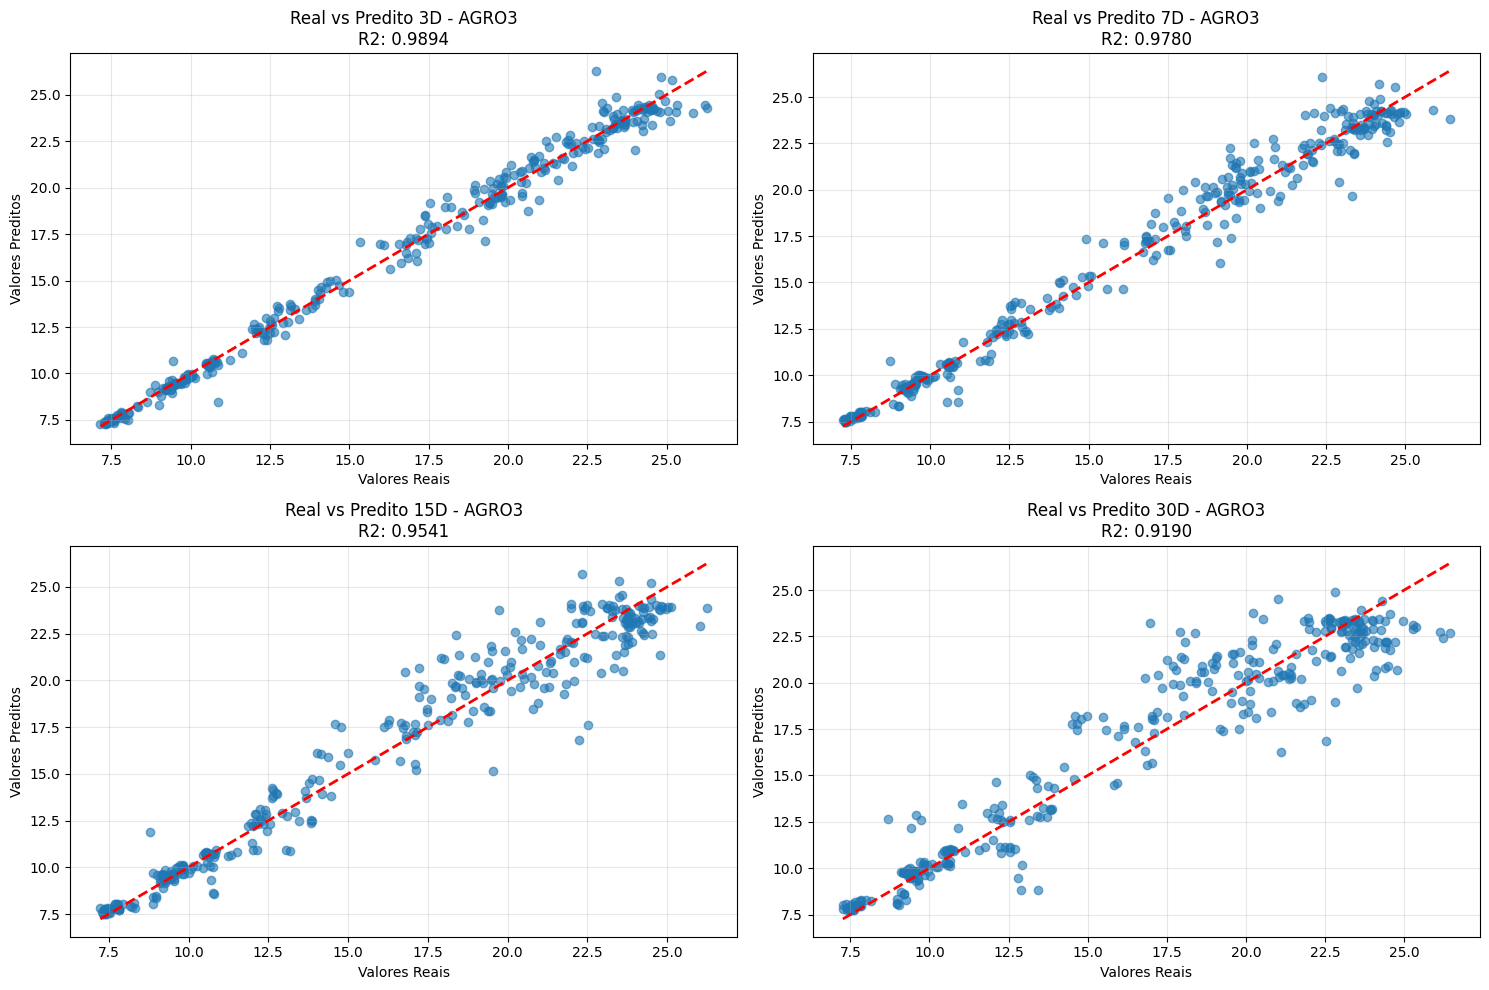

OK - Grafico real vs predito salvo


In [7]:
# Graficos Real vs Predito
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']

    # Plotar
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6)

    # Linha diagonal y=x (predicao perfeita)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

    ax.set_title(f'Real vs Predito {period.upper()} - AGRO3\nR2: {model_data["r2"]:.4f}')
    ax.set_xlabel('Valores Reais')
    ax.set_ylabel('Valores Preditos')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}real_vs_predito_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico real vs predito salvo')

### Comparacao das Metricas (R2 e MAE)

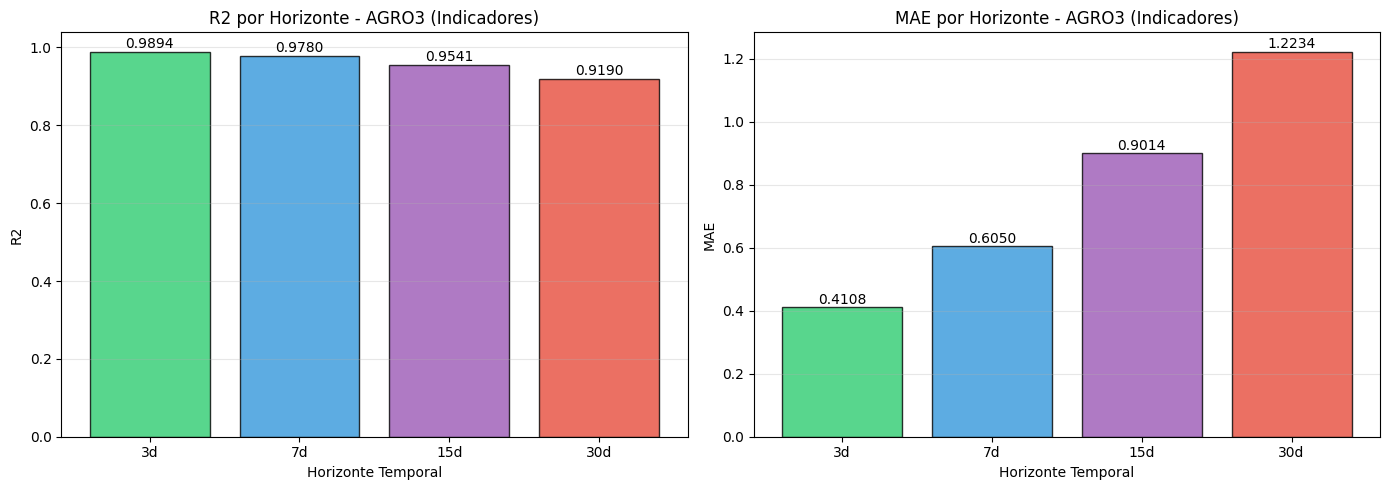

OK - Grafico de comparacao de metricas salvo


In [8]:
# Comparacao das metricas entre horizontes
periods = ['3d', '7d', '15d', '30d']
r2_values = [models[p]['r2'] for p in periods]
mae_values = [models[p]['mae'] for p in periods]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grafico R2
x = np.arange(len(periods))
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

ax1.bar(x, r2_values, color=colors, alpha=0.8, edgecolor='black')
ax1.set_xlabel('Horizonte Temporal')
ax1.set_ylabel('R2')
ax1.set_title('R2 por Horizonte - AGRO3 (Indicadores)')
ax1.set_xticks(x)
ax1.set_xticklabels(periods)
ax1.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for i, v in enumerate(r2_values):
    ax1.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

# Grafico MAE
ax2.bar(x, mae_values, color=colors, alpha=0.8, edgecolor='black')
ax2.set_xlabel('Horizonte Temporal')
ax2.set_ylabel('MAE')
ax2.set_title('MAE por Horizonte - AGRO3 (Indicadores)')
ax2.set_xticks(x)
ax2.set_xticklabels(periods)
ax2.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for i, v in enumerate(mae_values):
    ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}comparacao_metricas_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico de comparacao de metricas salvo')

### Histogramas dos Residuos

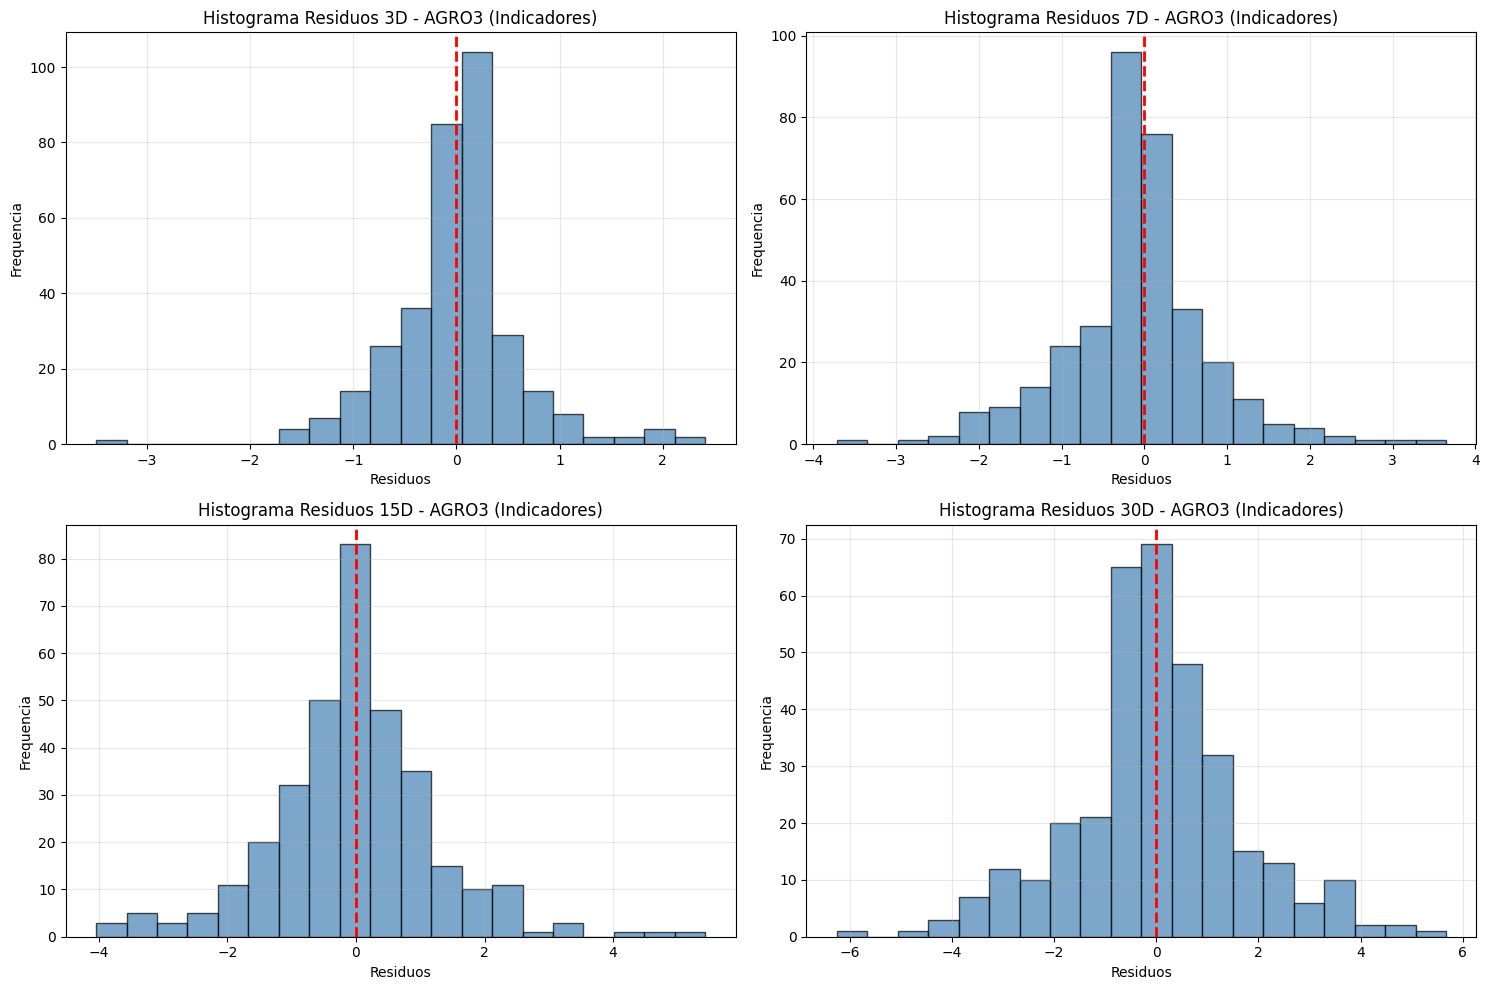

OK - Histograma de residuos salvo


In [9]:
# Histogramas dos residuos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    residuos = y_test - y_pred

    # Plotar
    ax = axes[idx]
    ax.hist(residuos, bins=20, alpha=0.7, edgecolor='black', color='steelblue')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Histograma Residuos {period.upper()} - AGRO3 (Indicadores)')
    ax.set_xlabel('Residuos')
    ax.set_ylabel('Frequencia')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}histograma_residuos_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Histograma de residuos salvo')

### Residuos vs Ordem Temporal

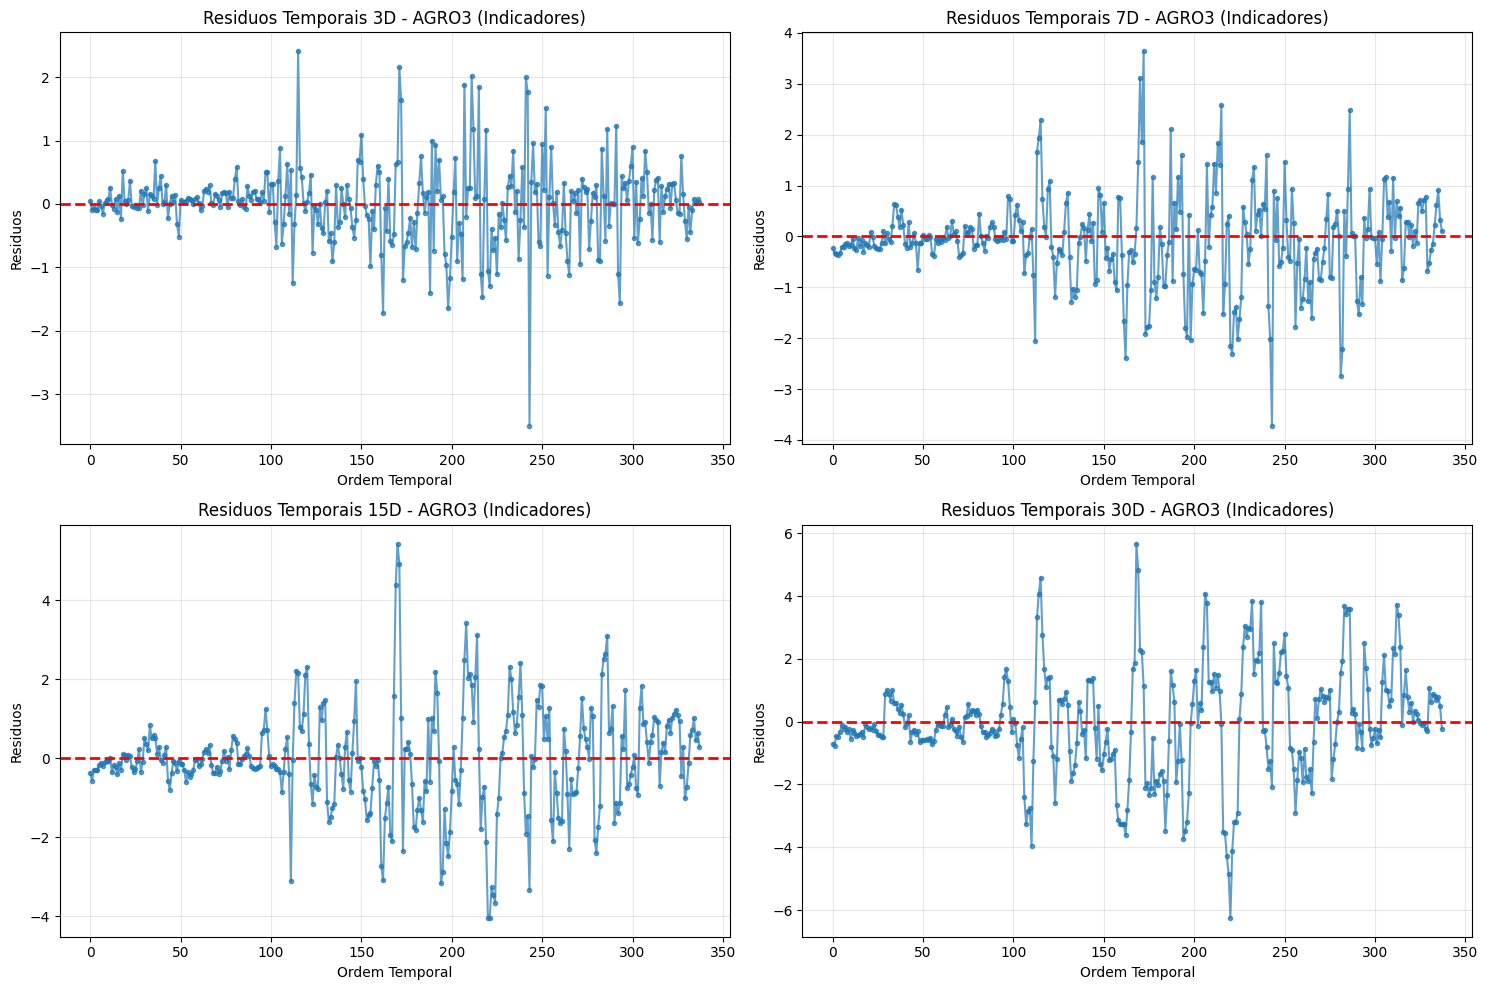

OK - Grafico de residuos temporais salvo


In [10]:
# Residuos vs Ordem Temporal
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    residuos = y_test - y_pred

    # Ordenar por indice temporal
    test_indices = model_data['X_test'].index
    sorted_indices = sorted(range(len(test_indices)), key=lambda i: test_indices[i])
    residuos_sorted = residuos.iloc[sorted_indices]

    # Plotar
    ax = axes[idx]
    ax.plot(range(len(residuos_sorted)), residuos_sorted, 'o-', markersize=3, alpha=0.7)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Residuos Temporais {period.upper()} - AGRO3 (Indicadores)')
    ax.set_xlabel('Ordem Temporal')
    ax.set_ylabel('Residuos')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}residuos_temporais_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico de residuos temporais salvo')

### Grafico de Dispersao com Intervalo de Confianca (IC 95%)

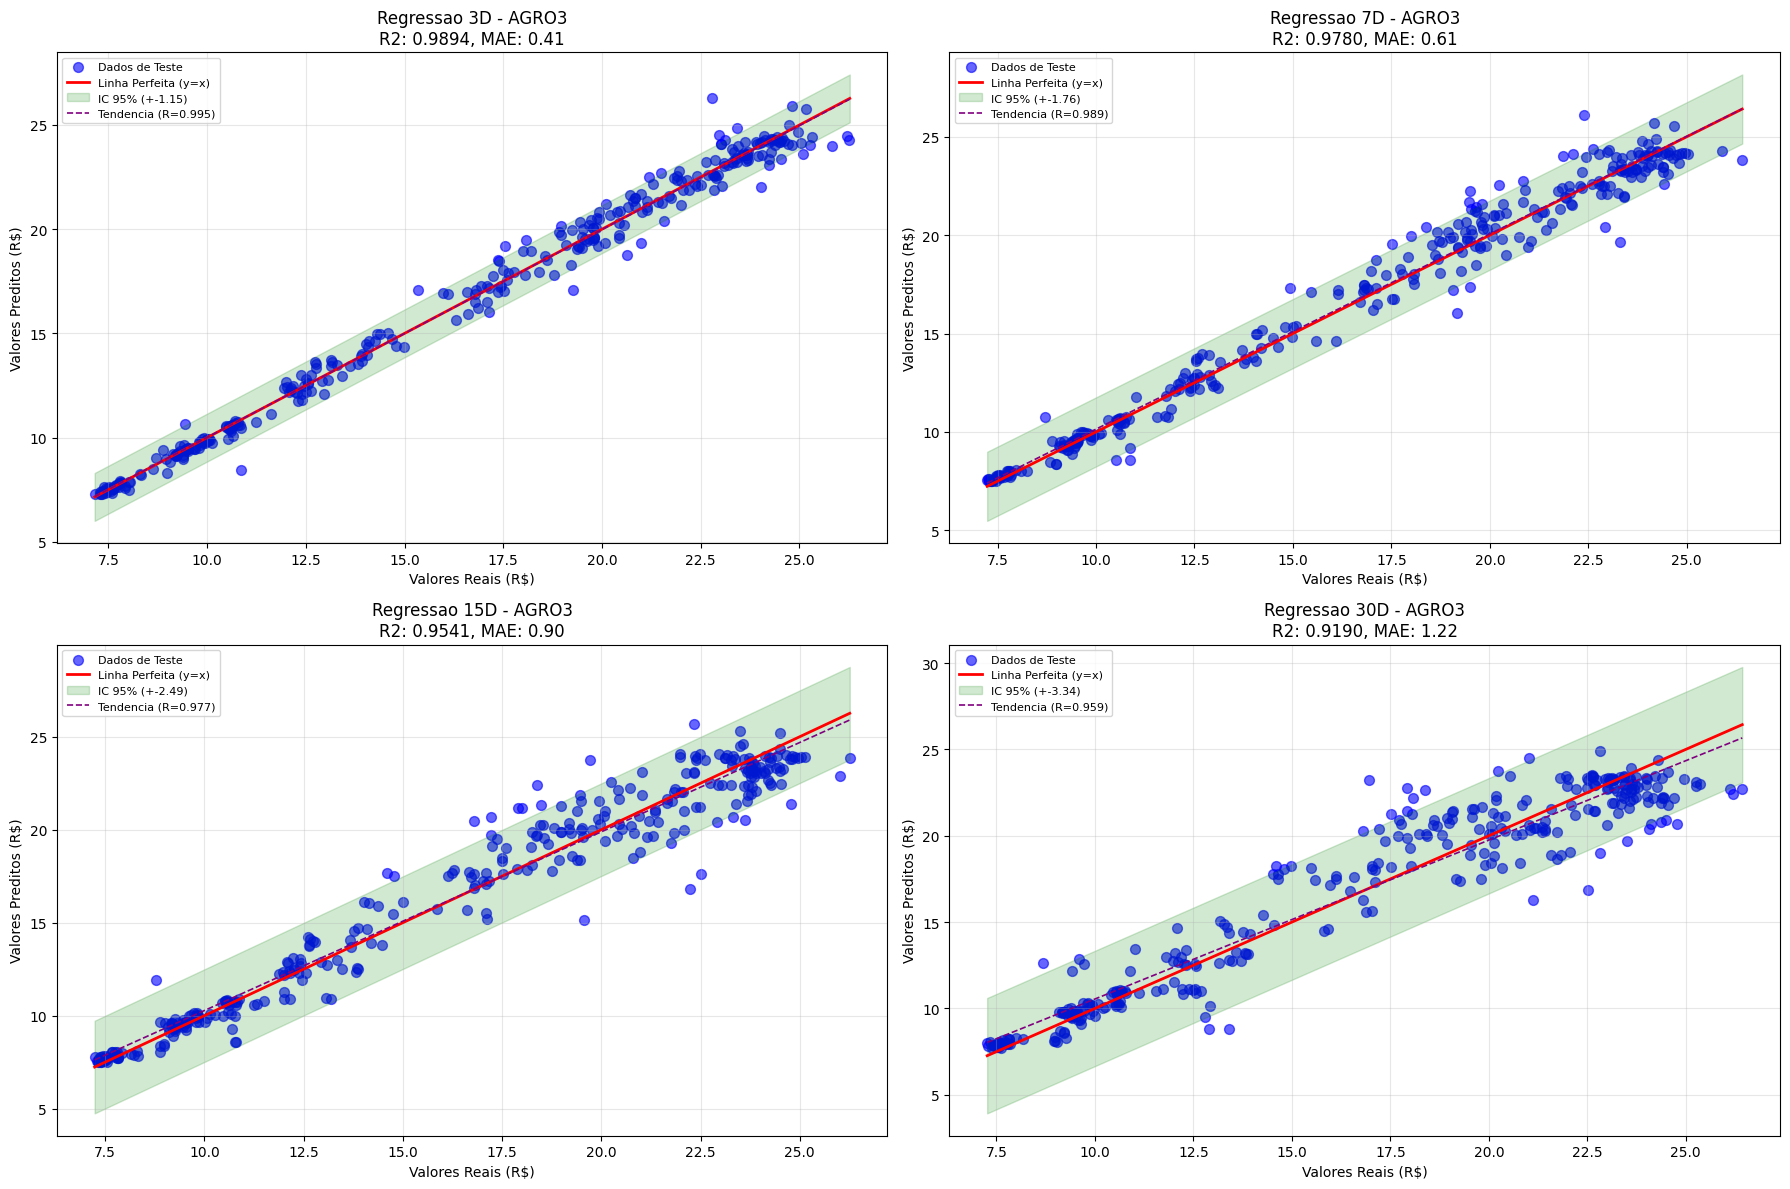

OK - Grafico de dispersao com IC 95% salvo


In [11]:
# Graficos de dispersao com linha de regressao e IC 95%
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    y_train = model_data['y_train']
    y_pred_train = model_data['model'].predict(model_data['X_train'])

    # Calcular MSE e desvio padrao dos residuos
    mse = mean_squared_error(y_train, y_pred_train)
    residual_std = np.sqrt(mse)

    ax = axes[idx]

    # Scatter dos dados de teste
    ax.scatter(y_test, y_pred, alpha=0.6, color='blue', s=50, label='Dados de Teste')

    # Linha y = x
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    line_vals = np.linspace(min_val, max_val, 100)
    ax.plot(line_vals, line_vals, 'r-', linewidth=2, label='Linha Perfeita (y=x)')

    # Intervalo de confianca 95%
    confidence_interval = 1.96 * residual_std
    ax.fill_between(line_vals,
                    line_vals - confidence_interval,
                    line_vals + confidence_interval,
                    alpha=0.18, color='green',
                    label=f'IC 95% (+-{confidence_interval:.2f})')

    # Linha de tendencia
    slope, intercept, r_value, p_value, std_err = stats.linregress(y_test, y_pred)
    regression_line = slope * line_vals + intercept
    ax.plot(line_vals, regression_line, '--', color='purple', linewidth=1.2, label=f'Tendencia (R={r_value:.3f})')

    ax.set_title(f'Regressao {period.upper()} - AGRO3\nR2: {model_data["r2"]:.4f}, MAE: {model_data["mae"]:.2f}')
    ax.set_xlabel('Valores Reais (R$)')
    ax.set_ylabel('Valores Preditos (R$)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}dispersao_ic_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico de dispersao com IC 95% salvo')

### Evolucao do R2 e MAE por Horizonte

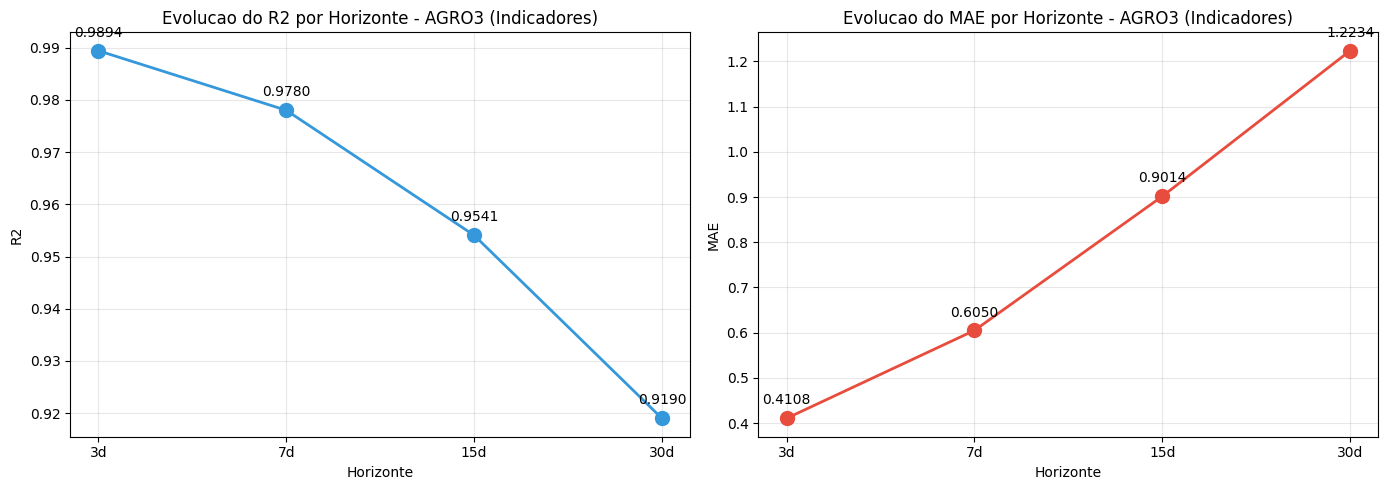

OK - Graficos de evolucao de R2 e MAE salvos


In [12]:
# Evolucao das metricas R2 e MAE por horizonte
periods = ['3d', '7d', '15d', '30d']
r2_values = [models[p]['r2'] for p in periods]
mae_values = [models[p]['mae'] for p in periods]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot R2
axes[0].plot(periods, r2_values, marker='o', linewidth=2, markersize=10, color='#3498db')
axes[0].set_title('Evolucao do R2 por Horizonte - AGRO3 (Indicadores)')
axes[0].set_xlabel('Horizonte')
axes[0].set_ylabel('R2')
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(r2_values):
    axes[0].annotate(f'{v:.4f}', (periods[i], v), textcoords='offset points', xytext=(0, 10), ha='center')

# Plot MAE
axes[1].plot(periods, mae_values, marker='o', linewidth=2, markersize=10, color='#e74c3c')
axes[1].set_title('Evolucao do MAE por Horizonte - AGRO3 (Indicadores)')
axes[1].set_xlabel('Horizonte')
axes[1].set_ylabel('MAE')
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(mae_values):
    axes[1].annotate(f'{v:.4f}', (periods[i], v), textcoords='offset points', xytext=(0, 10), ha='center')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}evolucao_metricas_agro3_indicadores.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Graficos de evolucao de R2 e MAE salvos')

### Resumo Final

In [13]:
print('\n' + '='*60)
print('RESUMO FINAL - REGRESSAO LINEAR VIA REDE NEURAL AGRO3 (DATASET INDICADORES)')
print('='*60)
print('\nOK - 4 modelos treinados (horizontes: 3d, 7d, 15d, 30d)')
print('OK - Features utilizadas: Close, Low, High, Open')
print('\nMetricas por horizonte:')
for period in ['3d', '7d', '15d', '30d']:
    print(f"  {period}: R2={models[period]['r2']:.4f}, MAE={models[period]['mae']:.4f}, RMSE={models[period]['rmse']:.4f}")

print('\nArquivos gerados:')
print('  - metricas_agro3_indicadores.csv')
print('  - serie_temporal_agro3_indicadores.png')
print('  - residuos_agro3_indicadores.png')
print('  - real_vs_predito_agro3_indicadores.png')
print('  - comparacao_metricas_agro3_indicadores.png')
print('  - histograma_residuos_agro3_indicadores.png')
print('  - residuos_temporais_agro3_indicadores.png')
print('  - dispersao_ic_agro3_indicadores.png')
print('  - evolucao_metricas_agro3_indicadores.png')
print('='*60)


RESUMO FINAL - REGRESSAO LINEAR VIA REDE NEURAL AGRO3 (DATASET INDICADORES)

OK - 4 modelos treinados (horizontes: 3d, 7d, 15d, 30d)
OK - Features utilizadas: Close, Low, High, Open

Metricas por horizonte:
  3d: R2=0.9894, MAE=0.4108, RMSE=0.6136
  7d: R2=0.9780, MAE=0.6050, RMSE=0.8775
  15d: R2=0.9541, MAE=0.9014, RMSE=1.2740
  30d: R2=0.9190, MAE=1.2234, RMSE=1.6779

Arquivos gerados:
  - metricas_agro3_indicadores.csv
  - serie_temporal_agro3_indicadores.png
  - residuos_agro3_indicadores.png
  - real_vs_predito_agro3_indicadores.png
  - comparacao_metricas_agro3_indicadores.png
  - histograma_residuos_agro3_indicadores.png
  - residuos_temporais_agro3_indicadores.png
  - dispersao_ic_agro3_indicadores.png
  - evolucao_metricas_agro3_indicadores.png
